In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sagarkumar009","key":"b24a4c4ba097257c0d7dbeb2d1830c8e"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d jessicali9530/celeba-dataset
!unzip -q celeba-dataset.zip -d /content/celeba

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [01:04<00:00, 22.2MB/s]



In [ ]:
!find /content/celeba -type d

/content/celeba
/content/celeba/img_align_celeba
/content/celeba/img_align_celeba/img_align_celeba


In [ ]:
DATA_DIR = "/content/celeba/img_align_celeba"

In [ ]:
import os
print(len(os.listdir(DATA_DIR)))

1


In [ ]:
print(len(os.listdir(DATA_DIR)))

1


In [ ]:
import os

print(os.listdir(DATA_DIR))

['img_align_celeba']


In [ ]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import time
import tensorflow as tf
from tensorflow.keras import layers
from IPython import display

# CelebA Dataset



In [ ]:
# CelebA dataset loading
IMG_SIZE = 64
DATA_DIR = "/content/celeba/img_align_celeba"  # change path if needed

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    labels=None,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=256,
    shuffle=True
)

train_dataset = train_dataset.map(lambda x: (tf.cast(x, tf.float32) - 127.5) / 127.5)


Found 202599 files.


In [ ]:
# Sample batch shape
for batch in train_dataset.take(1):
    print(batch.shape)

(256, 64, 64, 3)


In [ ]:
# Dataset ready for training

In [ ]:
# Images are already resized and normalized in the dataset pipeline

(60000, 28, 28, 1)


# Buffer and Batch Size

In [ ]:
BUFFER_SIZE = 30000
BATCH_SIZE = 256

# Shuffle the imaage

In [ ]:
# Dataset already batched above

# Initialise the Generator Models


In [ ]:
def make_generator_model():
  model = tf.keras.Sequential()
  model.add(layers.Dense(8*8*256, use_bias=False, input_shape=(100,)))
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU())

  model.add(layers.Reshape((8,8,256)))

  model.add(layers.Conv2DTranspose(128,(5,5),strides=(2,2),padding='same',use_bias=False))
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU())

  model.add(layers.Conv2DTranspose(64,(5,5),strides=(2,2),padding='same',use_bias=False))
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU())

  model.add(layers.Conv2DTranspose(32,(5,5),strides=(2,2),padding='same',use_bias=False))
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU())

  model.add(layers.Conv2DTranspose(3,(5,5),strides=(1,1),padding='same',use_bias=False,activation='tanh'))
  return model

generator = make_generator_model()
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16384)          │     1,638,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        51,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │         2,400 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,782,432 (10.61 MB)

 Trainable params: 2,749,216 (10.49 MB)

 Non-trainable params: 33,216 (129.75 KB)

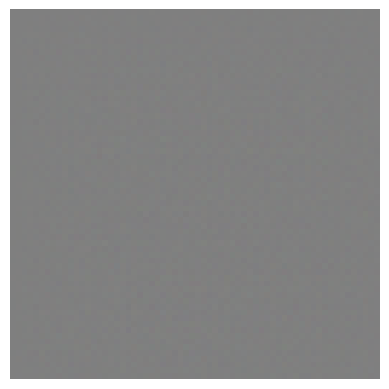

In [ ]:
noise = tf.random.normal([1,100])
generated_image = generator(noise,training=False)
plt.imshow((generated_image[0] + 1)/2)
plt.axis('off')
plt.show()

In [ ]:
def make_dicriminator_model():
  model = tf.keras.Sequential()
  model.add(layers.Conv2D(64,(5,5),strides=(2,2),padding='same',input_shape=[64,64,3]))
  model.add(layers.LeakyReLU())
  model.add(layers.Dropout(0.3))

  model.add(layers.Conv2D(128,(5,5),strides=(2,2),padding='same'))
  model.add(layers.LeakyReLU())
  model.add(layers.Dropout(0.3))

  model.add(layers.Conv2D(256,(5,5),strides=(2,2),padding='same'))
  model.add(layers.LeakyReLU())
  model.add(layers.Dropout(0.3))

  model.add(layers.Flatten())
  model.add(layers.Dense(1))
  return model

discriminator = make_dicriminator_model()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,045,633 (3.99 MB)

 Trainable params: 1,045,633 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

# Pass to the geneerator without training

In [ ]:
decision = discriminator(generated_image)
print("Discriminator output:",decision)

Discriminator output: tf.Tensor([[6.9933885e-05]], shape=(1, 1), dtype=float32)


In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# Discriminator Loss

In [ ]:
# This method quamtifies how well the discriminator is able to distinguish real images from fake images.
# It compares the discriminator predictions on real images to an array of 1 and fake on array of 0

In [ ]:
def discriminator_loss(real_output,fake_output):
  real_loss = cross_entropy(tf.ones_like(real_output),real_output)
  fake_loss = cross_entropy(tf.zeros_like(fake_output),fake_output)
  total_loss = real_loss+fake_loss
  return total_loss

# Generator Loss

In [ ]:
def generator_loss(fake_output):
  return cross_entropy(tf.ones_like(fake_output),fake_output)

In [ ]:
generator_optimizers = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizers  =tf.keras.optimizers.Adam(1e-4)

In [ ]:
checkpoint_dir = './training_checkpoints'
checkpoints_prefix = os.path.join(checkpoint_dir,"ckpt")

if not os.path.exists(checkpoint_dir):
  os.makedirs(checkpoint_dir)

checkpoint = tf.train.Checkpoint(generator_optimizers=generator_optimizers,
                                 discriminator_optimizers=discriminator_optimizers,
                                 generator=generator,
                                 discriminator=discriminator)

In [ ]:
EPOCHS = 10
noise_dim = 100
num_examples_to_generate = 16


seed = tf.random.normal([num_examples_to_generate,noise_dim])

In [ ]:
@tf.function
def train__step(images):
  noise = tf.random.normal([BATCH_SIZE,noise_dim])
  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    generated_images = generator(noise,training=True)
    real_output = discriminator(images,training=True)
    fake_output = discriminator(generated_images,training=True)
    gen_loss = generator_loss(fake_output)
    disc_loss = discriminator_loss(real_output,fake_output)

  gradient_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
  gradient_of_discriminator = disc_tape.gradient(disc_loss,discriminator.trainable_variables)

  generator_optimizers.apply_gradients(zip(gradient_of_generator,generator.trainable_variables))
  discriminator_optimizers.apply_gradients(zip(gradient_of_discriminator,discriminator.trainable_variables))


# All train_step function the following actions in one training
 The train_step function performs the following actions in one training iteration:

  Generate Random Noise:
  Creates a batch of random noise vectors to feed into the generator.

  Generate Fake Images:
  Uses the generator to create fake images from the noise.

  Get Discriminator Predictions:
  Feeds real images and fake images into the discriminator to get predictions.

  Calculate Losses:
  Computes the loss for both the generator and discriminator based on their performance.

  Compute Gradients:
  Calculates how the weights should be adjusted to minimize the losses.

  Update Weights:
  Adjusts the weights of both the generator and discriminator using the computed gradients and their respective optimizers.


In [ ]:
def generate_and_save_images(model,epoch,test_input):
  predictions = model(test_input,training=False)
  predictions = (predictions + 1)/2.0
  fig = plt.figure(figsize=(4,4))
  for i in range(predictions.shape[0]):
    plt.subplot(4,4,i+1)
    plt.imshow(predictions[i])
    plt.axis('off')
  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

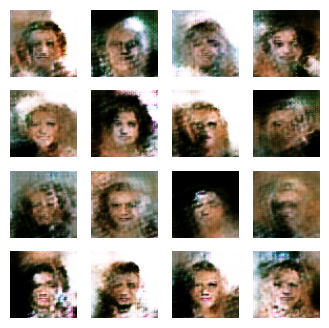

Time for epoch 1 is 285.38 sec


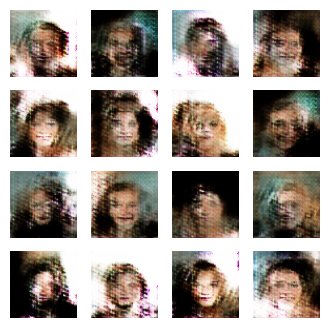

Time for epoch 2 is 284.72 sec


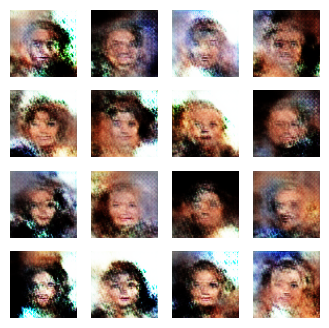

Time for epoch 3 is 284.51 sec


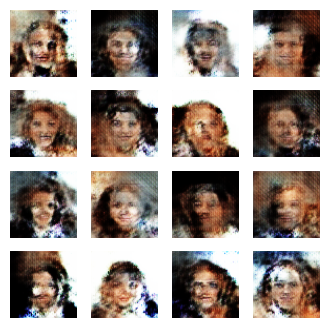

Time for epoch 4 is 284.76 sec


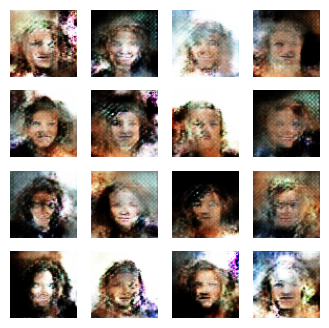

Time for epoch 5 is 284.20 sec


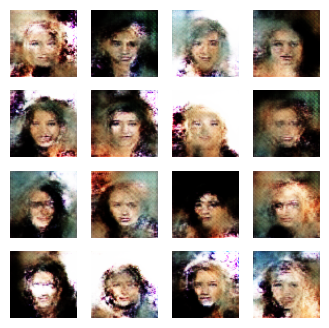

Time for epoch 6 is 285.00 sec


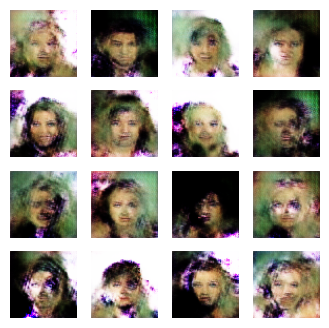

Time for epoch 7 is 322.24 sec


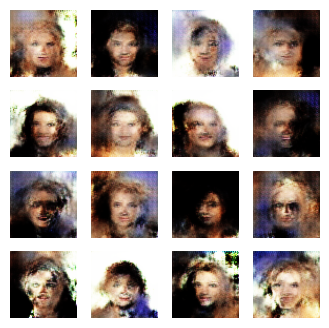

Time for epoch 8 is 285.26 sec


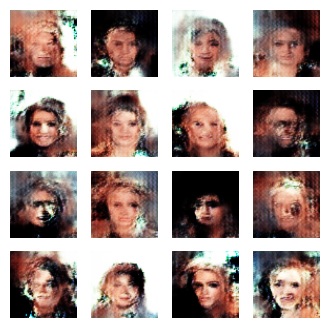

Time for epoch 9 is 283.49 sec


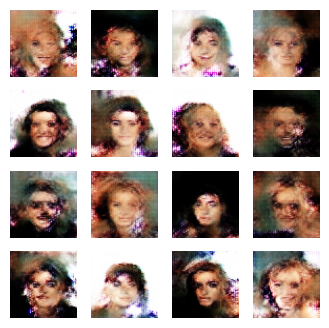

Time for epoch 10 is 284.10 sec


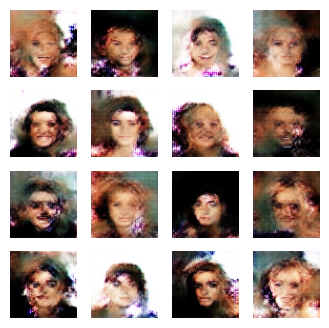

In [ ]:
def train(dataset,epochs):
  for epoch in range(epochs):
    start= time.time()

    for image_batch in dataset:
      train__step(image_batch)

    generate_and_save_images(generator, epoch +1, seed)

    if (epoch + 1) % 10 == 0:
      generator.save(
        f"generator_epoch_{epoch+1}.keras"
    )

    if(epoch+1)%15 ==0:
      checkpoint.save(file_prefix=checkpoints_prefix)
    print('Time for epoch {} is {:.2f} sec'.format(epoch + 1,time.time() - start))

  generate_and_save_images(generator,  epochs, seed)
train(train_dataset,EPOCHS)



# Conditional Gans left

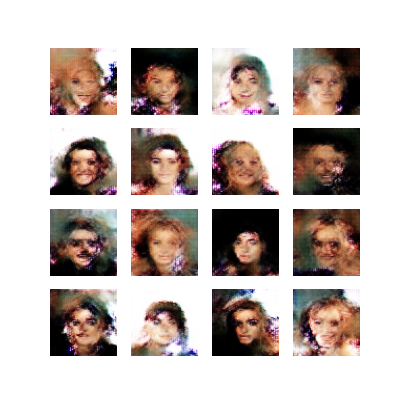

In [ ]:
# Restore the latest checkpoint (if needed)
# This can be used to resume training or generate images from a saved model
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

# Function to display a single image generated after a specific epoch
def display_image(epoch_no):
    return PIL.Image.open(
        'image_at_epoch_{:04d}.png'.format(epoch_no)
    )

# Display the image generated after the final epoch
display_image(EPOCHS)

Save the model

In [ ]:
generator.save('generator_model_final.keras')
print("Generator model saved to 'generator_model.h5'")

Generator model saved to 'generator_model.h5'


Generator model loaded successfully.


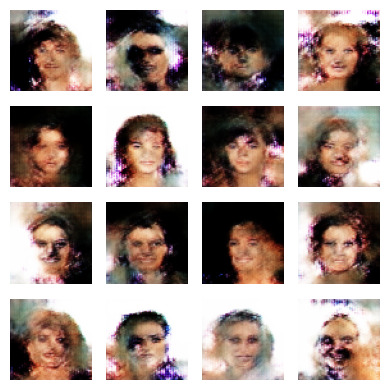

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the saved generator model
generator_trained = tf.keras.models.load_model('generator_model_final.keras')
print("Generator model loaded successfully.")

# Function to generate and display images
def generate_images(generator, num_images=16, noise_dim=100):
    # Generate random noise vectors
    noise = tf.random.normal([num_images, noise_dim])

    # Generate images using the loaded generator
    generated_images = generator(noise, training=False)

    # Rescale images from [-1, 1] to [0, 1] for display
    generated_images = (generated_images + 1) / 2.0
    #plot
    plt.figure(figsize=(4,4))
    for i in range(num_images):
      plt.subplot(4,4,i+1)
      plt.imshow(generated_images[i])
      plt.axis('off')
    plt.tight_layout()
    plt.show()
generate_images(generator_trained)

In [ ]:
from google.colab import files

files.download('/content/generator_model_final.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
with open("requirements.txt", "w") as f:
    f.write("""streamlit
tensorflow
numpy
matplotlib
pillow
""")

In [ ]:
from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>